<a href="https://colab.research.google.com/github/Massimomfls/MA289-Project-3-Comparative-Analysis-of-Data-Standardization-Techniques/blob/main/Comparative_Analysis_of_Data_Standardization_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Comparative Analysis of Data Standardization Techniques

No Scaling Accuracy: 0.8691
StandardScaler Accuracy: 0.9132
MinMaxScaler Accuracy: 0.8959
RobustScaler Accuracy: 0.8959


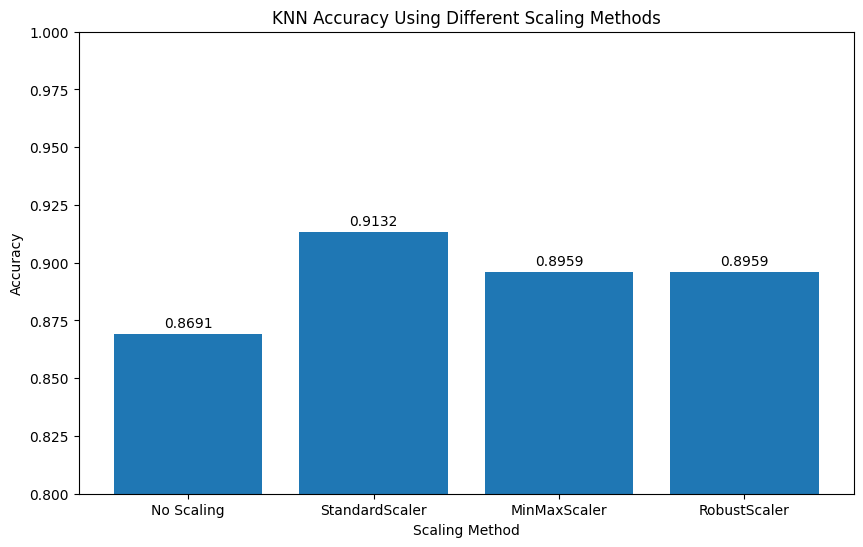

In [5]:
# ============================================================
# PROJECT 3 - COMPARING SCALING METHODS USING KNN
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

# Remove weight because it is a proxy for obesity
df = df.drop(columns=['Weight'])

# Create binary target:
# 1 = Obese
# 0 = Not Obese

df['Obese'] = df['NObeyesdad'].apply(lambda x: 1 if 'Obesity' in x else 0)
df = df.drop(columns=['NObeyesdad'])

# Encode categorical variables into numbers

for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])

# =========================
# SPLIT FEATURES AND TARGET
# =========================

X = df.drop(columns=['Obese'])
y = df['Obese']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ============================================================
# KNN WITHOUT SCALING
# ============================================================

knn_no_scaling = KNeighborsClassifier(n_neighbors=5)
knn_no_scaling.fit(X_train, y_train)

y_pred_no_scaling = knn_no_scaling.predict(X_test)

accuracy_no_scaling = accuracy_score(
    y_test,
    y_pred_no_scaling
)

# ============================================================
# STANDARD SCALER
# ============================================================

standard_scaler = StandardScaler()

X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

knn_standard = KNeighborsClassifier(n_neighbors=5)
knn_standard.fit(X_train_standard, y_train)

y_pred_standard = knn_standard.predict(X_test_standard)

accuracy_standard = accuracy_score(
    y_test,
    y_pred_standard
)

# ============================================================
# MINMAX SCALER
# ============================================================

minmax_scaler = MinMaxScaler()

X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

knn_minmax = KNeighborsClassifier(n_neighbors=5)
knn_minmax.fit(X_train_minmax, y_train)

y_pred_minmax = knn_minmax.predict(X_test_minmax)

accuracy_minmax = accuracy_score(
    y_test,
    y_pred_minmax
)

# ============================================================
# ROBUST SCALER
# ============================================================

robust_scaler = RobustScaler()

X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

knn_robust = KNeighborsClassifier(n_neighbors=5)
knn_robust.fit(X_train_robust, y_train)

y_pred_robust = knn_robust.predict(X_test_robust)

accuracy_robust = accuracy_score(
    y_test,
    y_pred_robust
)

# =========================
# PRINT RESULTS
# =========================

print("No Scaling Accuracy:", round(accuracy_no_scaling, 4))
print("StandardScaler Accuracy:", round(accuracy_standard, 4))
print("MinMaxScaler Accuracy:", round(accuracy_minmax, 4))
print("RobustScaler Accuracy:", round(accuracy_robust, 4))

# =========================
# BAR GRAPH OF ACCURACIES
# =========================

methods = [
    'No Scaling',
    'StandardScaler',
    'MinMaxScaler',
    'RobustScaler'
]

accuracies = [
    accuracy_no_scaling,
    accuracy_standard,
    accuracy_minmax,
    accuracy_robust
]

plt.figure(figsize=(10,6))

bars = plt.bar(methods, accuracies)

# Add accuracy values above bars

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        round(height, 4),
        ha='center'
    )

plt.ylabel("Accuracy")
plt.xlabel("Scaling Method")

plt.title(
    "KNN Accuracy Using Different Scaling Methods"
)

plt.ylim(0.80, 1.0)

plt.show()

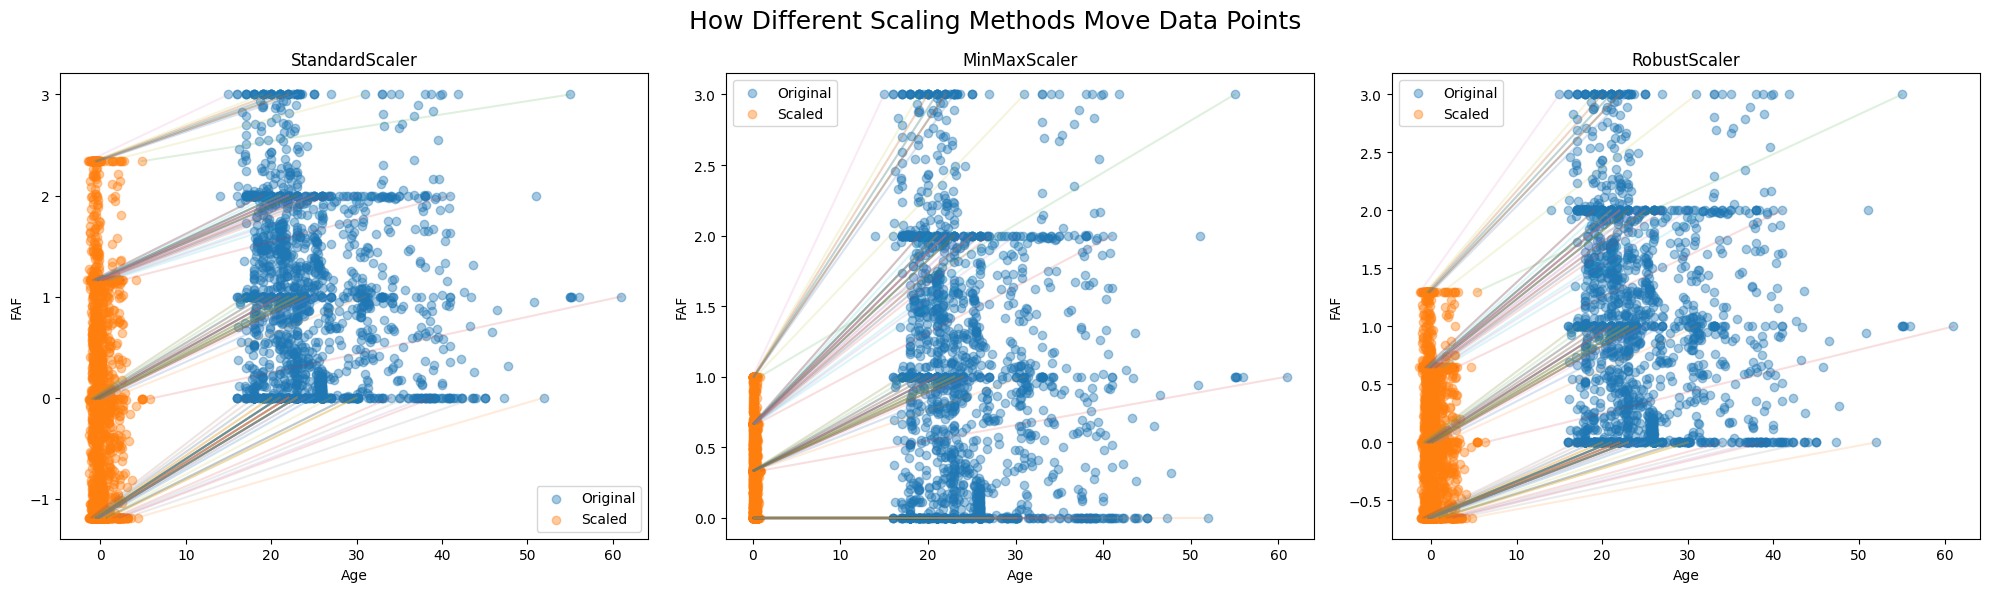

In [4]:
# =========================
# VISUALIZING HOW POINTS MOVE
# FOR DIFFERENT SCALING METHODS
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df = df.drop(columns=['Weight'])

# Create binary target
df['Obese'] = df['NObeyesdad'].apply(lambda x: 1 if 'Obesity' in x else 0)
df = df.drop(columns=['NObeyesdad'])

# Encode categorical features
for column in df.columns:
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])

# =========================
# SELECT FEATURES
# =========================

feature_1 = 'Age'
feature_2 = 'FAF'
X = df[[feature_1, feature_2]].copy()

# =========================
# CREATE SCALERS
# =========================

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

# Apply scaling
X_standard = standard_scaler.fit_transform(X)
X_minmax = minmax_scaler.fit_transform(X)
X_robust = robust_scaler.fit_transform(X)

# =========================
# CREATE SUBPLOTS
# =========================

fig, axes = plt.subplots(1, 3, figsize=(20,6))

# =========================
# STANDARD SCALER
# =========================

axes[0].scatter(X[feature_1], X[feature_2], alpha=0.4, label='Original')
axes[0].scatter(X_standard[:,0], X_standard[:,1], alpha=0.4, label='Scaled')

for i in range(150):
    axes[0].plot(
        [X.iloc[i][feature_1], X_standard[i,0]],
        [X.iloc[i][feature_2], X_standard[i,1]],
        alpha=0.15
    )

axes[0].set_title("StandardScaler")
axes[0].set_xlabel(feature_1)
axes[0].set_ylabel(feature_2)
axes[0].legend()

# =========================
# MINMAX SCALER
# =========================

axes[1].scatter(X[feature_1], X[feature_2], alpha=0.4, label='Original')
axes[1].scatter(X_minmax[:,0], X_minmax[:,1], alpha=0.4, label='Scaled')

for i in range(150):
    axes[1].plot(
        [X.iloc[i][feature_1], X_minmax[i,0]],
        [X.iloc[i][feature_2], X_minmax[i,1]],
        alpha=0.15
    )

axes[1].set_title("MinMaxScaler")
axes[1].set_xlabel(feature_1)
axes[1].set_ylabel(feature_2)
axes[1].legend()

# =========================
# ROBUST SCALER
# =========================

axes[2].scatter(X[feature_1], X[feature_2], alpha=0.4, label='Original')
axes[2].scatter(X_robust[:,0], X_robust[:,1], alpha=0.4, label='Scaled')

for i in range(150):
    axes[2].plot(
        [X.iloc[i][feature_1], X_robust[i,0]],
        [X.iloc[i][feature_2], X_robust[i,1]],
        alpha=0.15
    )

axes[2].set_title("RobustScaler")
axes[2].set_xlabel(feature_1)
axes[2].set_ylabel(feature_2)
axes[2].legend()

# =========================
# FINAL FORMATTING
# =========================

fig.suptitle("How Different Scaling Methods Move Data Points", fontsize=18)
plt.tight_layout()
plt.show()